In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [85]:
clinic_df = pd.read_csv("../X_train/clinical_train.csv")
molecular_df = pd.read_csv("../X_train/molecular_train.csv")
target = pd.read_csv("../target_train.csv")

In [86]:
clinic_df

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
0,P132697,MSK,14.0,2.80,0.20,0.70,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]"
1,P132698,MSK,1.0,7.40,2.40,0.10,11.6,42.0,"46,xx"
2,P116889,MSK,15.0,3.70,2.10,0.10,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]"
3,P132699,MSK,1.0,3.90,1.90,0.10,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]"
4,P132700,MSK,6.0,128.00,9.70,0.90,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]"
...,...,...,...,...,...,...,...,...,...
3318,P121828,VU,1.0,3.70,2.53,0.53,8.9,499.0,"46,xy[20]"
3319,P121829,VU,0.0,4.20,2.40,0.22,10.6,49.0,"46,xy,del(13)(q12q14)[1]/45,x,-y,del(13)(q12q1..."
3320,P121830,VU,0.0,1.80,0.55,0.29,9.4,86.0,"46,xy,del(20)(q11.2q13.1)[4]/45,xy,idem,-7[16]"
3321,P121853,VU,5.0,1.37,0.37,0.11,11.4,102.0,"46,xx,del(1)(p34)[5]/45,xx,sl,-18[12]/46,xx,sd..."


In [87]:
molecular_df

,ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
0,P100000,11,119149248.0,119149248.0,G,A,CBL,p.C419Y,non_synonymous_codon,0.0830,1308.0
1,P100000,5,131822301.0,131822301.0,G,T,IRF1,p.Y164*,stop_gained,0.0220,532.0
2,P100000,3,77694060.0,77694060.0,G,C,ROBO2,p.?,splice_site_variant,0.4100,876.0
3,P100000,4,106164917.0,106164917.0,G,T,TET2,p.R1262L,non_synonymous_codon,0.4300,826.0
4,P100000,2,25468147.0,25468163.0,ACGAAGAGGGGGTGTTC,A,DNMT3A,p.E505fs*141,frameshift_variant,0.0898,942.0
...,...,...,...,...,...,...,...,...,...,...,...
10930,P131472,NaN,NaN,NaN,NaN,NaN,MLL,MLL_PTD,PTD,NaN,NaN
10931,P131505,NaN,NaN,NaN,NaN,NaN,MLL,MLL_PTD,PTD,NaN,NaN
10932,P131816,NaN,NaN,NaN,NaN,NaN,MLL,MLL_PTD,PTD,NaN,NaN
10933,P132717,NaN,NaN,NaN,NaN,NaN,MLL,MLL_PTD,PTD,NaN,NaN


In [88]:
target

,ID,OS_YEARS,OS_STATUS
0,P132697,1.115068,1.0
1,P132698,4.928767,0.0
2,P116889,2.043836,0.0
3,P132699,2.476712,1.0
4,P132700,3.145205,0.0
...,...,...,...
3318,P121828,NaN,NaN
3319,P121829,NaN,NaN
3320,P121830,1.997260,0.0
3321,P121853,0.095890,1.0


In [89]:
print(len(clinic_df['ID'].unique()))
print(len(molecular_df['ID'].unique()))
print(len(target['ID'].unique()))

3323
3026
3323


In [90]:
molecular_df_latest = molecular_df.drop_duplicates(subset=['ID'], keep='last')

In [91]:
df_all = clinic_df.merge(molecular_df_latest, on=['ID'], how='left')
df_all

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
0,P132697,MSK,14.0,2.80,0.20,0.70,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",4,106190822.0,106190822.0,C,T,TET2,p.P1367L,non_synonymous_codon,0.3940,1351.0
1,P132698,MSK,1.0,7.40,2.40,0.10,11.6,42.0,"46,xx",21,36171643.0,36171644.0,T,TG,RUNX1,p.S308fs*292,frameshift_variant,0.2661,1043.0
2,P116889,MSK,15.0,3.70,2.10,0.10,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]",11,32414263.0,32414263.0,G,A,WT1,p.R430*,stop_gained,0.0350,1482.0
3,P132699,MSK,1.0,3.90,1.90,0.10,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]",12,49224338.0,49224338.0,G,A,DDX23,p.P793S,non_synonymous_codon,0.4770,1000.0
4,P132700,MSK,6.0,128.00,9.70,0.90,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]",20,31022441.0,31022442.0,A,AG,ASXL1,p.G646fs*12,frameshift_variant,0.4721,713.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3318,P121828,VU,1.0,3.70,2.53,0.53,8.9,499.0,"46,xy[20]",20,31022441.0,31022442.0,A,AG,ASXL1,p.G646fs*12,frameshift_variant,0.3840,556.0
3319,P121829,VU,0.0,4.20,2.40,0.22,10.6,49.0,"46,xy,del(13)(q12q14)[1]/45,x,-y,del(13)(q12q1...",X,53432008.0,53432008.0,C,T,SMC1A,p.R711Q,non_synonymous_codon,0.0420,743.0
3320,P121830,VU,0.0,1.80,0.55,0.29,9.4,86.0,"46,xy,del(20)(q11.2q13.1)[4]/45,xy,idem,-7[16]",1,43818424.0,43818425.0,GC,G,MPL,p.Y631fs*>5,frameshift_variant,0.1799,1270.0
3321,P121853,VU,5.0,1.37,0.37,0.11,11.4,102.0,"46,xx,del(1)(p34)[5]/45,xx,sl,-18[12]/46,xx,sd...",17,7578536.0,7578536.0,T,G,TP53,p.K132Q,non_synonymous_codon,0.1830,1422.0


In [92]:
df_all = df_all.merge(target, on=['ID'])
df_all

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,CHR,...,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH,OS_YEARS,OS_STATUS
0,P132697,MSK,14.0,2.80,0.20,0.70,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",4,...,106190822.0,C,T,TET2,p.P1367L,non_synonymous_codon,0.3940,1351.0,1.115068,1.0
1,P132698,MSK,1.0,7.40,2.40,0.10,11.6,42.0,"46,xx",21,...,36171644.0,T,TG,RUNX1,p.S308fs*292,frameshift_variant,0.2661,1043.0,4.928767,0.0
2,P116889,MSK,15.0,3.70,2.10,0.10,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]",11,...,32414263.0,G,A,WT1,p.R430*,stop_gained,0.0350,1482.0,2.043836,0.0
3,P132699,MSK,1.0,3.90,1.90,0.10,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]",12,...,49224338.0,G,A,DDX23,p.P793S,non_synonymous_codon,0.4770,1000.0,2.476712,1.0
4,P132700,MSK,6.0,128.00,9.70,0.90,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]",20,...,31022442.0,A,AG,ASXL1,p.G646fs*12,frameshift_variant,0.4721,713.0,3.145205,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3318,P121828,VU,1.0,3.70,2.53,0.53,8.9,499.0,"46,xy[20]",20,...,31022442.0,A,AG,ASXL1,p.G646fs*12,frameshift_variant,0.3840,556.0,NaN,NaN
3319,P121829,VU,0.0,4.20,2.40,0.22,10.6,49.0,"46,xy,del(13)(q12q14)[1]/45,x,-y,del(13)(q12q1...",X,...,53432008.0,C,T,SMC1A,p.R711Q,non_synonymous_codon,0.0420,743.0,NaN,NaN
3320,P121830,VU,0.0,1.80,0.55,0.29,9.4,86.0,"46,xy,del(20)(q11.2q13.1)[4]/45,xy,idem,-7[16]",1,...,43818425.0,GC,G,MPL,p.Y631fs*>5,frameshift_variant,0.1799,1270.0,1.997260,0.0
3321,P121853,VU,5.0,1.37,0.37,0.11,11.4,102.0,"46,xx,del(1)(p34)[5]/45,xx,sl,-18[12]/46,xx,sd...",17,...,7578536.0,T,G,TP53,p.K132Q,non_synonymous_codon,0.1830,1422.0,0.095890,1.0


In [93]:
df_all.isna().sum()

ID                  0
CENTER              0
BM_BLAST          109
WBC               272
ANC               193
MONOCYTES         601
HB                110
PLT               124
CYTOGENETICS      387
CHR               405
START             405
END               405
REF               405
ALT               405
GENE              297
PROTEIN_CHANGE    305
EFFECT            297
VAF               386
DEPTH             405
OS_YEARS          150
OS_STATUS         150
dtype: int64

In [94]:
df = df_all[(~df_all["OS_YEARS"].isna()) & (~df_all["OS_STATUS"].isna())]
df

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,CHR,...,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH,OS_YEARS,OS_STATUS
0,P132697,MSK,14.0,2.80,0.20,0.70,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",4,...,106190822.0,C,T,TET2,p.P1367L,non_synonymous_codon,0.3940,1351.0,1.115068,1.0
1,P132698,MSK,1.0,7.40,2.40,0.10,11.6,42.0,"46,xx",21,...,36171644.0,T,TG,RUNX1,p.S308fs*292,frameshift_variant,0.2661,1043.0,4.928767,0.0
2,P116889,MSK,15.0,3.70,2.10,0.10,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]",11,...,32414263.0,G,A,WT1,p.R430*,stop_gained,0.0350,1482.0,2.043836,0.0
3,P132699,MSK,1.0,3.90,1.90,0.10,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]",12,...,49224338.0,G,A,DDX23,p.P793S,non_synonymous_codon,0.4770,1000.0,2.476712,1.0
4,P132700,MSK,6.0,128.00,9.70,0.90,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]",20,...,31022442.0,A,AG,ASXL1,p.G646fs*12,frameshift_variant,0.4721,713.0,3.145205,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3316,P121826,VU,1.0,2.50,1.02,0.20,10.2,78.0,"47~49,xy,+21,+21,+22[cp11]/46,xy[10]",2,...,25457242.0,C,T,DNMT3A,p.R882H,non_synonymous_codon,0.0560,1006.0,0.547945,0.0
3317,P121827,VU,1.5,8.10,2.66,0.45,11.3,40.0,"44,xx,inv(2)(p25q31),-4,del(5)(q12q33),-18[20]",17,...,7577539.0,G,A,TP53,p.R248W,non_synonymous_codon,0.8190,722.0,2.339726,0.0
3320,P121830,VU,0.0,1.80,0.55,0.29,9.4,86.0,"46,xy,del(20)(q11.2q13.1)[4]/45,xy,idem,-7[16]",1,...,43818425.0,GC,G,MPL,p.Y631fs*>5,frameshift_variant,0.1799,1270.0,1.997260,0.0
3321,P121853,VU,5.0,1.37,0.37,0.11,11.4,102.0,"46,xx,del(1)(p34)[5]/45,xx,sl,-18[12]/46,xx,sd...",17,...,7578536.0,T,G,TP53,p.K132Q,non_synonymous_codon,0.1830,1422.0,0.095890,1.0


In [95]:
df.columns

Index(['ID', 'CENTER', 'BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT',
       'CYTOGENETICS', 'CHR', 'START', 'END', 'REF', 'ALT', 'GENE',
       'PROTEIN_CHANGE', 'EFFECT', 'VAF', 'DEPTH', 'OS_YEARS', 'OS_STATUS'],
      dtype='object')

In [96]:
df['CENTER'].unique()

array(['MSK', 'CCH', 'CGM', 'DUS', 'DUTH', 'FLO', 'FUCE', 'GESMD', 'HIAE',
       'HMS', 'ICO', 'IHBT', 'KI', 'MUV', 'PV', 'REL', 'RMCN', 'ROM',
       'TUD', 'UMG', 'UOB', 'UOXF', 'VU'], dtype=object)

array([[<Axes: title={'center': 'BM_BLAST'}>,
        <Axes: title={'center': 'WBC'}>, <Axes: title={'center': 'ANC'}>],
       [<Axes: title={'center': 'MONOCYTES'}>,
        <Axes: title={'center': 'HB'}>, <Axes: title={'center': 'PLT'}>],
       [<Axes: title={'center': 'START'}>,
        <Axes: title={'center': 'END'}>, <Axes: title={'center': 'VAF'}>],
       [<Axes: title={'center': 'DEPTH'}>,
        <Axes: title={'center': 'OS_YEARS'}>,
        <Axes: title={'center': 'OS_STATUS'}>]], dtype=object)

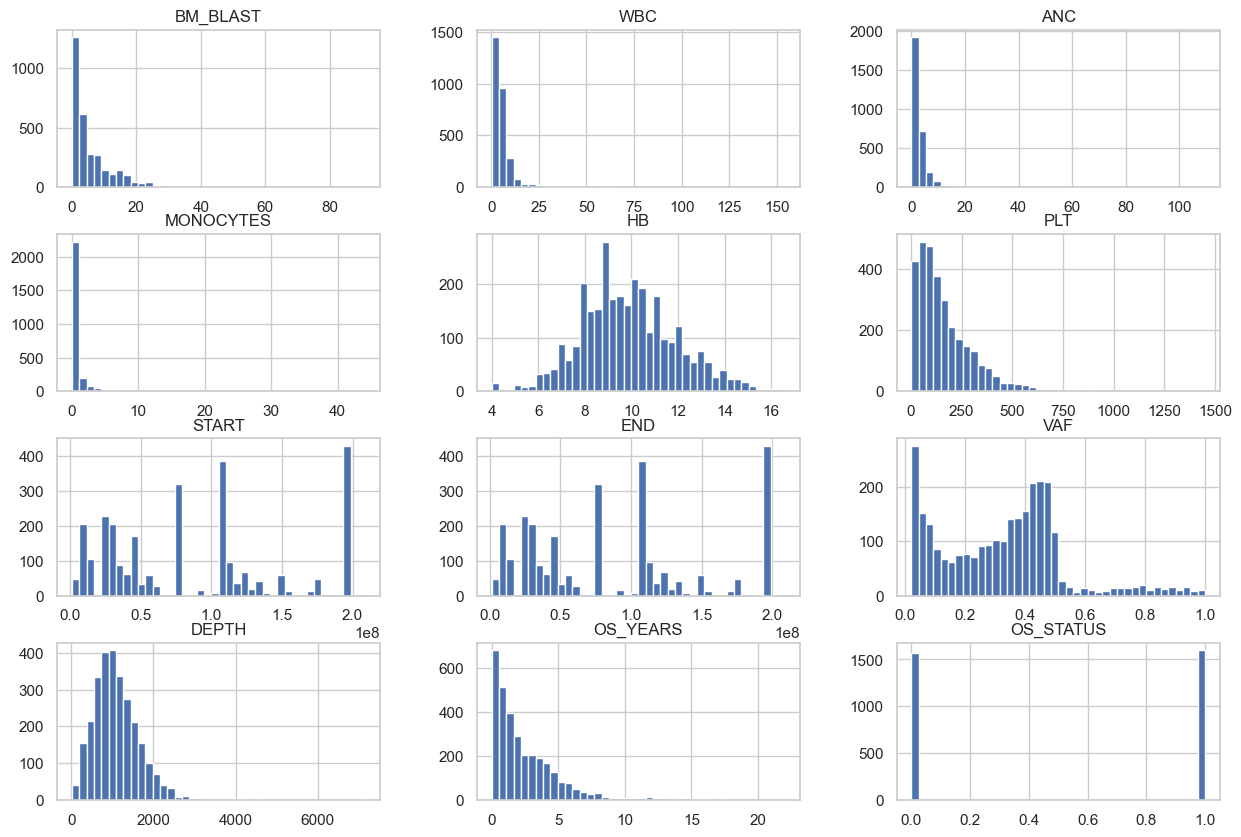

In [97]:
df.hist(figsize=(15, 10), bins=40)

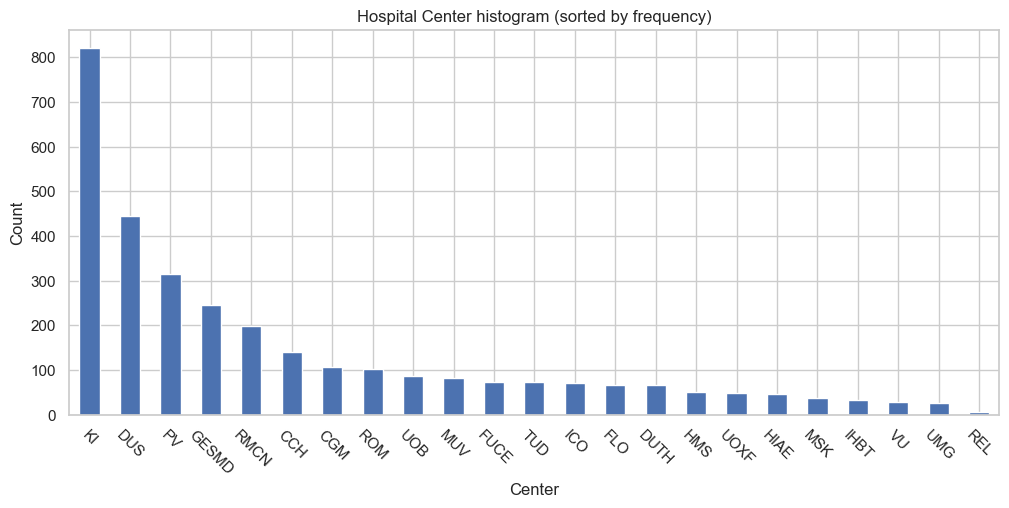

In [98]:
value_counts = df["CENTER"].value_counts().sort_values(ascending=False)  # or ascending=True
value_counts
# Plot as bar chart
ax = value_counts.plot(kind='bar', figsize=(12, 5))
ax.set_title("Hospital Center histogram (sorted by frequency)")
ax.set_xlabel("Center")
ax.set_ylabel("Count")
plt.xticks(rotation=-45)
plt.show()

array([[<Axes: title={'center': 'WBC'}>, <Axes: title={'center': 'ANC'}>],
       [<Axes: title={'center': 'HB'}>, <Axes: title={'center': 'PLT'}>]],
      dtype=object)

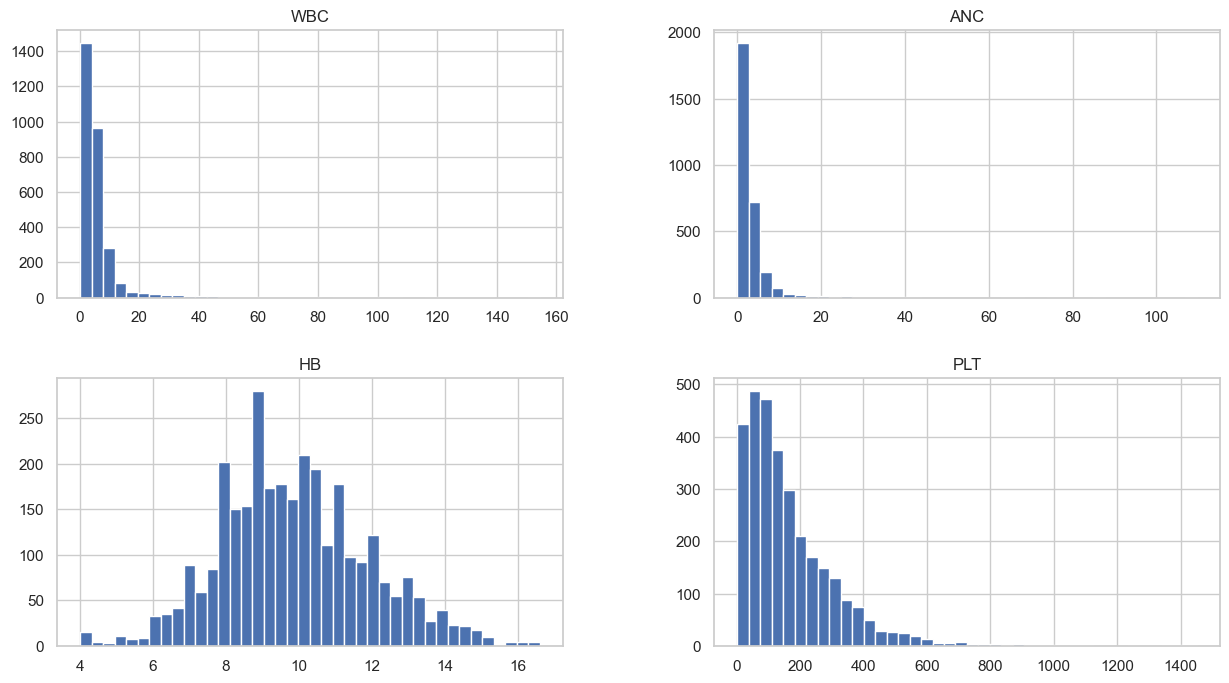

In [99]:
df[['WBC', 'ANC', 'HB', 'PLT']].hist(figsize=(15, 8), bins=40)

/var/folders/xn/c1tmz0cs43b7pr7_v59qy69w0000gp/T/ipykernel_5836/2152220151.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "log_WBC"] = np.log(df["WBC"] + 1)
/var/folders/xn/c1tmz0cs43b7pr7_v59qy69w0000gp/T/ipykernel_5836/2152220151.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "log_ANC"] = np.log(df["ANC"] + 1)
/var/folders/xn/c1tmz0cs43b7pr7_v59qy69w0000gp/T/ipykernel_5836/2152220151.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

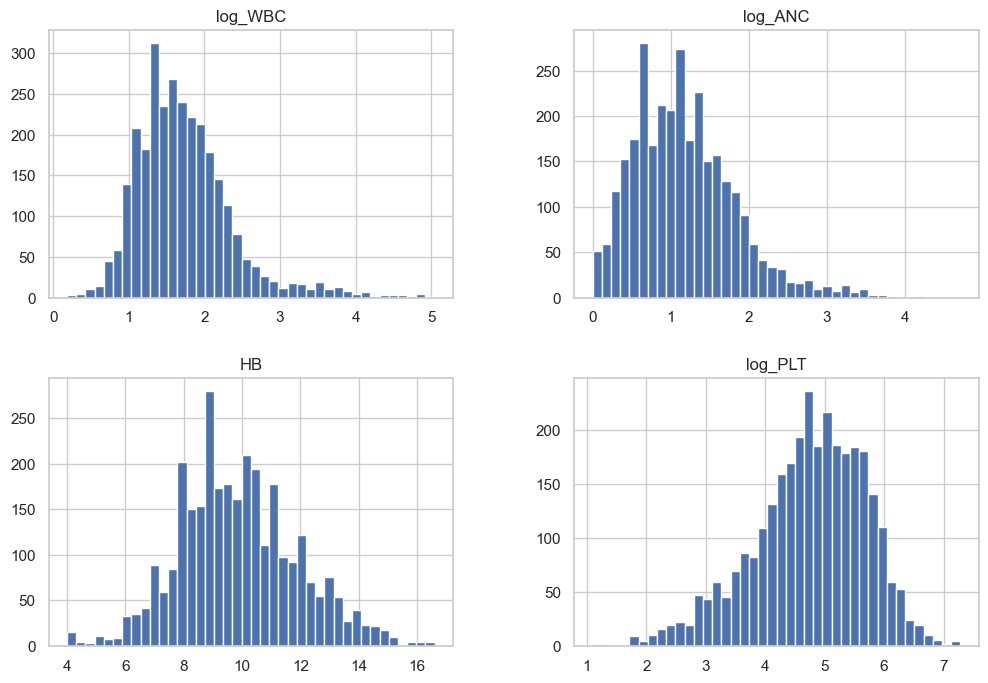

In [100]:
df.loc[:, "log_WBC"] = np.log(df["WBC"] + 1)
df.loc[:, "log_ANC"] = np.log(df["ANC"] + 1)
df.loc[:, "log_PLT"] = np.log(df["PLT"] + 1)

ax = df[["log_WBC", "log_ANC", "HB", "log_PLT"]].hist(figsize=(12, 8), bins=40)

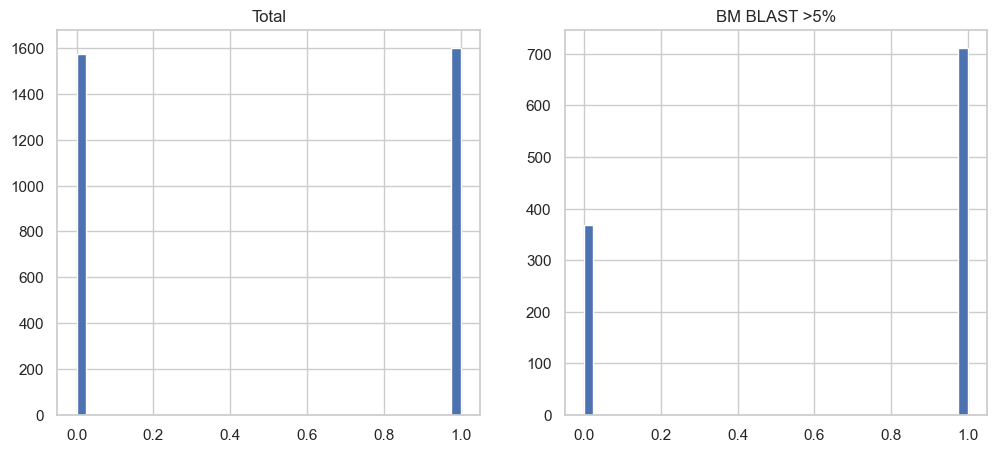

In [101]:
over_df = df[df["BM_BLAST"] > 5].copy()
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Total")
plt.hist(df["OS_STATUS"], bins=40)
plt.subplot(1, 2, 2)
plt.title("BM BLAST >5%")
plt.hist(over_df["OS_STATUS"], bins=40)
plt.show()

In [102]:
df

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,CHR,...,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH,OS_YEARS,OS_STATUS,log_WBC,log_ANC,log_PLT
0,P132697,MSK,14.0,2.80,0.20,0.70,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",4,...,TET2,p.P1367L,non_synonymous_codon,0.3940,1351.0,1.115068,1.0,1.335001,0.182322,4.787492
1,P132698,MSK,1.0,7.40,2.40,0.10,11.6,42.0,"46,xx",21,...,RUNX1,p.S308fs*292,frameshift_variant,0.2661,1043.0,4.928767,0.0,2.128232,1.223775,3.761200
2,P116889,MSK,15.0,3.70,2.10,0.10,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]",11,...,WT1,p.R430*,stop_gained,0.0350,1482.0,2.043836,0.0,1.547563,1.131402,4.406719
3,P132699,MSK,1.0,3.90,1.90,0.10,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]",12,...,DDX23,p.P793S,non_synonymous_codon,0.4770,1000.0,2.476712,1.0,1.589235,1.064711,4.356709
4,P132700,MSK,6.0,128.00,9.70,0.90,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]",20,...,ASXL1,p.G646fs*12,frameshift_variant,0.4721,713.0,3.145205,0.0,4.859812,2.370244,5.278115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3316,P121826,VU,1.0,2.50,1.02,0.20,10.2,78.0,"47~49,xy,+21,+21,+22[cp11]/46,xy[10]",2,...,DNMT3A,p.R882H,non_synonymous_codon,0.0560,1006.0,0.547945,0.0,1.252763,0.703098,4.369448
3317,P121827,VU,1.5,8.10,2.66,0.45,11.3,40.0,"44,xx,inv(2)(p25q31),-4,del(5)(q12q33),-18[20]",17,...,TP53,p.R248W,non_synonymous_codon,0.8190,722.0,2.339726,0.0,2.208274,1.297463,3.713572
3320,P121830,VU,0.0,1.80,0.55,0.29,9.4,86.0,"46,xy,del(20)(q11.2q13.1)[4]/45,xy,idem,-7[16]",1,...,MPL,p.Y631fs*>5,frameshift_variant,0.1799,1270.0,1.997260,0.0,1.029619,0.438255,4.465908
3321,P121853,VU,5.0,1.37,0.37,0.11,11.4,102.0,"46,xx,del(1)(p34)[5]/45,xx,sl,-18[12]/46,xx,sd...",17,...,TP53,p.K132Q,non_synonymous_codon,0.1830,1422.0,0.095890,1.0,0.862890,0.314811,4.634729


In [103]:
cyto = df[["ID", "CYTOGENETICS", "OS_YEARS", "OS_STATUS"]]
cyto[:5]

,ID,CYTOGENETICS,OS_YEARS,OS_STATUS
0,P132697,"46,xy,del(20)(q12)[2]/46,xy[18]",1.115068,1.0
1,P132698,"46,xx",4.928767,0.0
2,P116889,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]",2.043836,0.0
3,P132699,"46,xy,del(3)(q26q27)[15]/46,xy[5]",2.476712,1.0
4,P132700,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]",3.145205,0.0


In [104]:
def engineer_cyto(values, id):
    res = {
        "ID": id,
        "chromo_count": None,
    }
    if values[0] == "nan":
        return res
    elif values[0] == "complex":
        return res
    if values[0].isdigit():
        res["chromo_count"] = int(values[0])
    return res


new_feature_df = pd.DataFrame()

for i in range(len(cyto)):
    row = cyto.iloc[i]
    values = str(row["CYTOGENETICS"]).split(",")
    features = pd.DataFrame(engineer_cyto(values, row["ID"]), index=[i])
    new_feature_df = pd.concat([new_feature_df, features])
new_feature_df

,ID,chromo_count
0,P132697,46
1,P132698,46
2,P116889,46
3,P132699,46
4,P132700,46
...,...,...
3168,P121826,None
3169,P121827,44
3170,P121830,46
3171,P121853,46


In [105]:
cyto_df = cyto.merge(new_feature_df, on=['ID'])
cyto_df

,ID,CYTOGENETICS,OS_YEARS,OS_STATUS,chromo_count
0,P132697,"46,xy,del(20)(q12)[2]/46,xy[18]",1.115068,1.0,46
1,P132698,"46,xx",4.928767,0.0,46
2,P116889,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]",2.043836,0.0,46
3,P132699,"46,xy,del(3)(q26q27)[15]/46,xy[5]",2.476712,1.0,46
4,P132700,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]",3.145205,0.0,46
...,...,...,...,...,...
3168,P121826,"47~49,xy,+21,+21,+22[cp11]/46,xy[10]",0.547945,0.0,None
3169,P121827,"44,xx,inv(2)(p25q31),-4,del(5)(q12q33),-18[20]",2.339726,0.0,44
3170,P121830,"46,xy,del(20)(q11.2q13.1)[4]/45,xy,idem,-7[16]",1.997260,0.0,46
3171,P121853,"46,xx,del(1)(p34)[5]/45,xx,sl,-18[12]/46,xx,sd...",0.095890,1.0,46


In [106]:
cyto_df['chromo_count'].unique()

array([46, 45, None, 47, 51, 44, 43, 50, 42, 48, 90, 52, 4445, 49, 53, 56,
       91, 54], dtype=object)

In [ ]:
from cytopy import CytoPy

lib = CytoPy()
df_cytogenics = lib.to_dataframe(cyto_df['CYTOGENETICS'].to_list())
df_cytogenics[['original_string', 'chr_count', 'sex', 'abnormalities', 'cell_count']].head(5)

,original_string,chr_count,sex,abnormalities,cell_count
0,"46,xy,del(20)(q12)[2]/46,xy[18]",46,xy,del(20)(q12),2
1,"46,xy,del(20)(q12)[2]/46,xy[18]",46,xy,,18
2,"46,xx",46,xx,normal,1
3,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]",46,xy,t(3;3)(q25;q27),8
4,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]",46,xy,,12


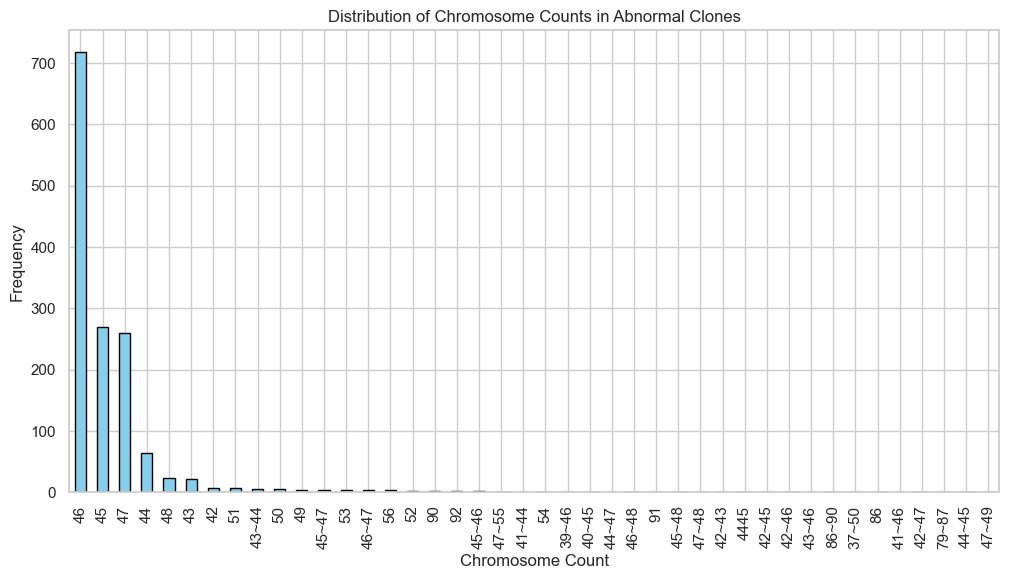

In [109]:
lib.visualize_abnormalities(df_cytogenics)